# Food Classification with ResNet50 Using Pytorch

This notebook implements a food classification model using transfer learning with ResNet50.

## Requirements Installation

Run this cell to install all required packages:

In [ ]:
!pip install torch>=2.0.0
!pip install torchvision>=0.15.0
!pip install numpy>=1.24.0
!pip install matplotlib>=3.7.0
!pip install Pillow>=9.5.0
!pip install torchsummary

## Import Libraries

In [ ]:
import torch, torchvision
from torchvision import datasets, models, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

## Device Configuration

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda:0


## Data Transforms

Define image transformations for training, validation, and testing.

In [ ]:
# Applying Transforms to the Data
image_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

## Load the Data

Set up data directories and load datasets.

In [ ]:
# Set train and valid directory paths

if os.path.exists("data_cleaned.zip"):
    print(">>> Extraction de data.zip en cours...")
    with zipfile.ZipFile("data_cleaned.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print(">>> Extraction terminée !")
else:
    print("ATTENTION : Fichier 'data.zip' introuvable. Veuillez l'uploader dans la colonne de gauche.")
dataset = 'data_cleaned'

train_directory = os.path.join(dataset, 'train')
valid_directory = os.path.join(dataset, 'val')

# Batch size
bs = 32

# Number of classes
num_classes = len(os.listdir(valid_directory))
print('Number of classes : ', num_classes)
num_epochs = 25
save_path = os.path.join('tl', dataset + '_'+ str(num_epochs)+'_epochs')
save_dir = os.path.join('models', save_path)
os.makedirs(save_dir, exist_ok=True)

Number of classes :  4


In [ ]:
# Load Data from folders
data = {
    'train': datasets.ImageFolder(root=train_directory, transform=image_transforms['train']),
    'valid': datasets.ImageFolder(root=valid_directory, transform=image_transforms['valid']),
}

# Get a mapping of the indices to the class names, in order to see the output classes of the test images.
idx_to_class = {v: k for k, v in data['train'].class_to_idx.items()}
print('Mapping idx/class: ', idx_to_class)

Mapping idx/class:  {0: 'banana', 1: 'pizza', 2: 'sushi', 3: 'tomato'}


In [ ]:
# Size of Data, to be used for calculating Average Loss and Accuracy
train_data_size = len(data['train'])
valid_data_size = len(data['valid'])

# Create iterators for the Data loaded using DataLoader module
train_data_loader = DataLoader(data['train'], batch_size=bs, shuffle=True)
valid_data_loader = DataLoader(data['valid'], batch_size=bs, shuffle=True)

print('train_data_size: ', train_data_size,'valid_data_size: ', valid_data_size)

train_data_size:  285 valid_data_size:  140


## Model Setup

Load pre-trained ResNet50 and modify for transfer learning.

In [ ]:
# Load pretrained ResNet50 Model
resnet50 = models.resnet50(pretrained=True)
resnet50 = resnet50.to(device)

# Freeze model parameters
for param in resnet50.parameters():
    param.requires_grad = False

# Change the final layer of ResNet50 Model for Transfer Learning
fc_inputs = resnet50.fc.in_features

resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes), # Since 4 possible outputs
    nn.LogSoftmax(dim=1) # For using NLLLoss()
)

# Convert model to be used on GPU
resnet50 = resnet50.to(device)

/root/miniconda3/envs/env_dl/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/env_dl/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Define Optimizer and Loss Function
loss_func = nn.NLLLoss()
optimizer = optim.Adam(resnet50.parameters())

In [ ]:
# Print the model to be trained
summary(resnet50, input_size=(3, 224, 224), batch_size=bs, device='cuda')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 64, 112, 112]           9,408
       BatchNorm2d-2         [32, 64, 112, 112]             128
              ReLU-3         [32, 64, 112, 112]               0
         MaxPool2d-4           [32, 64, 56, 56]               0
            Conv2d-5           [32, 64, 56, 56]           4,096
       BatchNorm2d-6           [32, 64, 56, 56]             128
              ReLU-7           [32, 64, 56, 56]               0
            Conv2d-8           [32, 64, 56, 56]          36,864
       BatchNorm2d-9           [32, 64, 56, 56]             128
             ReLU-10           [32, 64, 56, 56]               0
           Conv2d-11          [32, 256, 56, 56]          16,384
      BatchNorm2d-12          [32, 256, 56, 56]             512
           Conv2d-13          [32, 256, 56, 56]          16,384
      BatchNorm2d-14          [32, 256,

## Training and Validation Function

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, epochs=25):
    '''
    Function to train and validate
    Parameters
        :param model: Model to train and validate
        :param loss_criterion: Loss Criterion to minimize
        :param optimizer: Optimizer for computing gradients
        :param epochs: Number of epochs (default=25)

    Returns
        model: Trained Model with best validation accuracy
        history: (dict object): Having training loss, accuracy and validation loss, accuracy
    '''

    start = time.time()
    history = []
    best_loss = 100000.0
    best_epoch = None

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        for i, (inputs, labels) in enumerate(train_data_loader):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

            print("Batch number: {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}".format(i, loss.item(), acc.item()))


        # Validation - No gradient tracking needed
        with torch.no_grad():

            # Set to evaluation mode
            model.eval()

            # Validation loop
            for j, (inputs, labels) in enumerate(valid_data_loader):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Forward pass - compute outputs on input data using the model
                outputs = model(inputs)

                # Compute loss
                loss = loss_criterion(outputs, labels)

                # Compute the total loss for the batch and add it to valid_loss
                valid_loss += loss.item() * inputs.size(0)

                # Calculate validation accuracy
                ret, predictions = torch.max(outputs.data, 1)
                correct_counts = predictions.eq(labels.data.view_as(predictions))

                # Convert correct_counts to float and then compute the mean
                acc = torch.mean(correct_counts.type(torch.FloatTensor))

                # Compute total accuracy in the whole batch and add to valid_acc
                valid_acc += acc.item() * inputs.size(0)

                print("Validation Batch number: {:03d}, Validation: Loss: {:.4f}, Accuracy: {:.4f}".format(j, loss.item(), acc.item()))
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_epoch = epoch

        # Find average training loss and training accuracy
        avg_train_loss = train_loss/train_data_size
        avg_train_acc = train_acc/train_data_size

        # Find average training loss and training accuracy
        avg_valid_loss = valid_loss/valid_data_size
        avg_valid_acc = valid_acc/valid_data_size

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss - {:.4f}, Accuracy - {:.4f}%, \n\t\tValidation : Loss - {:.4f}, Accuracy - {:.4f}%, Time: {:.4f}s".format(epoch, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, epoch_end-epoch_start))

        # Save if the model has best accuracy till now
    torch.save(model, os.path.join('models',save_path,'_model_')+str(epochs)+'.pt')

    return model, history, best_epoch

## Train the Model

In [ ]:
# Train the model for 25 epochs
num_epochs = num_epochs
trained_model, history, best_epoch = train_and_validate(resnet50, loss_func, optimizer, num_epochs)

Epoch: 1/25
Batch number: 000, Training: Loss: 1.3779, Accuracy: 0.2812
Batch number: 001, Training: Loss: 1.4302, Accuracy: 0.3438
Batch number: 002, Training: Loss: 1.0678, Accuracy: 0.5625
Batch number: 003, Training: Loss: 1.3339, Accuracy: 0.5312
Batch number: 004, Training: Loss: 1.0167, Accuracy: 0.5625
Batch number: 005, Training: Loss: 0.8040, Accuracy: 0.7812
Batch number: 006, Training: Loss: 0.7220, Accuracy: 0.7812
Batch number: 007, Training: Loss: 0.5580, Accuracy: 0.8438
Batch number: 008, Training: Loss: 0.6394, Accuracy: 0.6897
Validation Batch number: 000, Validation: Loss: 0.3975, Accuracy: 0.9062
Validation Batch number: 001, Validation: Loss: 0.2851, Accuracy: 1.0000
Validation Batch number: 002, Validation: Loss: 0.3428, Accuracy: 0.8750
Validation Batch number: 003, Validation: Loss: 0.2680, Accuracy: 0.9375
Validation Batch number: 004, Validation: Loss: 0.4182, Accuracy: 0.9167
Epoch : 000, Training: Loss - 0.9982, Accuracy - 59.6491%, 
		Validation : Loss - 0

## Save Training History

In [ ]:
torch.save(history, os.path.join('models',save_path,'_history') + '.pt')


## Visualize Training Results

Plot loss and accuracy curves.

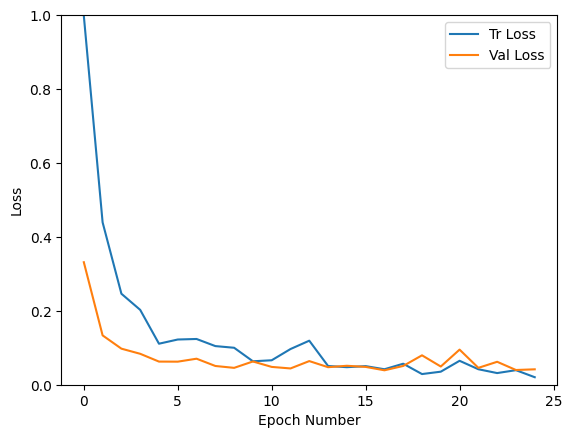

In [ ]:
history = np.array(history)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
plt.savefig(os.path.join('models',save_path,'_loss_curve') + '.png')
plt.show()

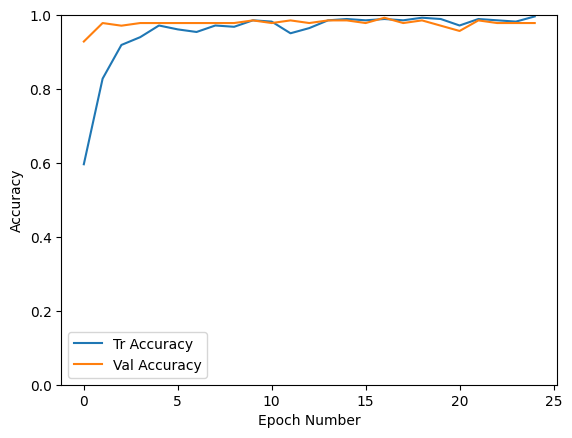

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.savefig(os.path.join('models',save_path,'_accruacy_curve') + '.png')
plt.show()

## Prediction Function

In [ ]:
def predict(model, test_image_name):
    '''
    Function to predict the class of a single test image
    Parameters
        :param model: Model to test
        :param test_image_name: Test image

    '''

    transform = image_transforms['test']


    test_image = Image.open(test_image_name)
    plt.imshow(test_image)

    test_image_tensor = transform(test_image)
    if torch.cuda.is_available():
        test_image_tensor = test_image_tensor.view(1, 3, 224, 224).cuda()
    else:
        test_image_tensor = test_image_tensor.view(1, 3, 224, 224)

    with torch.no_grad():
        model.eval()
        # Model outputs log probabilities
        out = model(test_image_tensor)
        ps = torch.exp(out)

        topk, topclass = ps.topk(4, dim=1)
        cls = idx_to_class[topclass.cpu().numpy()[0][0]]
        score = topk.cpu().numpy()[0][0]

        for i in range(3):
            print("Predcition", i+1, ":", idx_to_class[topclass.cpu().numpy()[0][i]], ", Score: ", topk.cpu().numpy()[0][i])

## Test Predictions

Load the trained model and make predictions on test images.

In [ ]:
dir_test = 'data/test'
model = torch.load(f"models/tl/data_{num_epochs}_epochs/_model_{num_epochs}.pt",weights_only=False)

==============================sushi==============================
Predcition 1 : sushi , Score:  0.9993045
Predcition 2 : pizza , Score:  0.0004302632
Predcition 3 : banana , Score:  0.00018768838


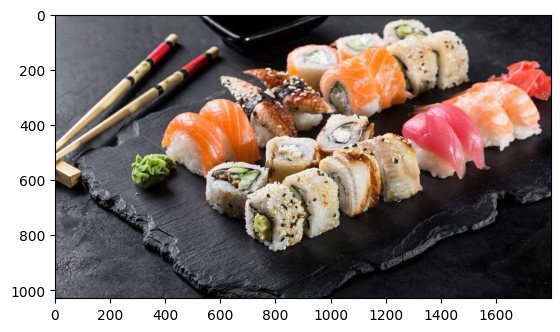

In [ ]:
print('='*30+ 'sushi' + '='*30)
predict(model,os.path.join(dir_test,'sushi.jpg'))

==============================pizza==============================
Predcition 1 : pizza , Score:  0.9834155
Predcition 2 : sushi , Score:  0.016511137
Predcition 3 : banana , Score:  3.916452e-05


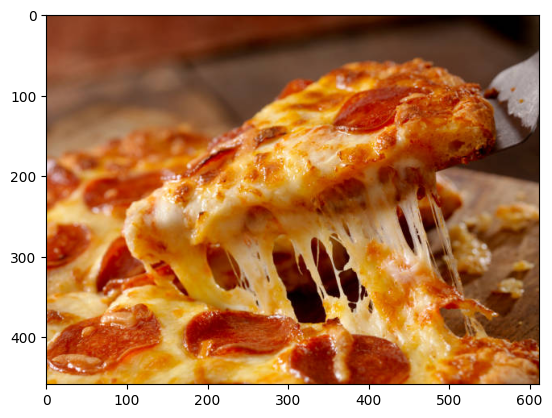

In [ ]:
print('='*30+ 'pizza' + '='*30)
predict(model,os.path.join(dir_test,'pizz.jpg'))

==============================tomato==============================
Predcition 1 : tomato , Score:  0.9999193
Predcition 2 : banana , Score:  4.826607e-05
Predcition 3 : sushi , Score:  2.6055004e-05


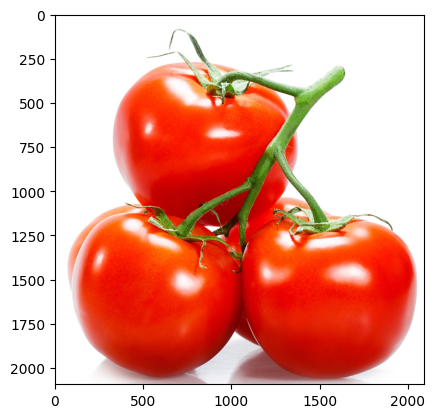

In [ ]:
print('='*30+ 'tomato' + '='*30)
predict(model,os.path.join(dir_test,'tomato.jpg'))

## Additional Functions (For Future Use)

Commented out test set accuracy computation function.

In [ ]:
# To try for later
# def computeTestSetAccuracy(model, loss_criterion):
#     '''
#     Function to compute the accuracy on the test set
#     Parameters
#         :param model: Model to test
#         :param loss_criterion: Loss Criterion to minimize
#     '''

#     device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#     test_acc = 0.0
#     test_loss = 0.0

#     # Validation - No gradient tracking needed
#     with torch.no_grad():

#         # Set to evaluation mode
#         model.eval()

#         # Validation loop
#         for j, (inputs, labels) in enumerate(test_data_loader):
#             inputs = inputs.to(device)
#             labels = labels.to(device)

#             # Forward pass - compute outputs on input data using the model
#             outputs = model(inputs)

#             # Compute loss
#             loss = loss_criterion(outputs, labels)

#             # Compute the total loss for the batch and add it to valid_loss
#             test_loss += loss.item() * inputs.size(0)

#             # Calculate validation accuracy
#             ret, predictions = torch.max(outputs.data, 1)
#             correct_counts = predictions.eq(labels.data.view_as(predictions))

#             # Convert correct_counts to float and then compute the mean
#             acc = torch.mean(correct_counts.type(torch.FloatTensor))

#             # Compute total accuracy in the whole batch and add to valid_acc
#             test_acc += acc.item() * inputs.size(0)

#             print("Test Batch number: {:03d}, Test: Loss: {:.4f}, Accuracy: {:.4f}".format(j, loss.item(), acc.item()))

#     # Find average test loss and test accuracy
#     avg_test_loss = test_loss/test_data_size
#     avg_test_acc = test_acc/test_data_size

#     print("Test accuracy : " + str(avg_test_acc))